In [1]:
"""
================================================================================
 Text Clustering e Topic Modeling — Versão em Português Brasileiro
 (dataset B2W Reviews + embeddings multilíngues + DeepSeek)
================================================================================

Material adaptado do Capítulo 5 de
    "Hands-On Large Language Models" (Jay Alammar & Maarten Grootendorst, 2024).

Adaptações principais em relação à versão original:

  • Dataset original (ArXiv abstracts em inglês) -> B2W Reviews (PT-BR)
  • Embedding model gte-small (inglês) -> paraphrase-multilingual-MiniLM-L12-v2
  • Stop words em inglês -> stop words em português
  • Tokenização adaptada para texto curto (reviews tendem a ter 1-3 frases)
  • Prompts em português para os labels gerados pelo LLM

Pré-requisitos:

    pip install -U sentence-transformers umap-learn hdbscan bertopic \
                   datasets matplotlib pandas python-dotenv nltk scikit-learn

    # Para usar o DeepSeek:
    pip install "bertopic[litellm]" litellm

Configuração da chave de API (DeepSeek):

    1. Conta em https://platform.deepseek.com
    2. Crie chave em "API Keys"
    3. Salve no .env na raiz do projeto:
       DEEPSEEK_API_KEY=sk-...
"""


# =============================================================================
# Bloco 0 — Configuração inicial (variáveis de ambiente)
# =============================================================================
import os
from dotenv import load_dotenv

load_dotenv("../.env")  # ajuste se .env estiver em outro lugar

print("DeepSeek configurado:", bool(os.environ.get("DEEPSEEK_API_KEY")))




DeepSeek configurado: True


In [5]:
# =============================================================================
# Bloco 1 (CORRIGIDO) — Carregando B2W Reviews via CSV direto do GitHub
# -----------------------------------------------------------------------------
# A versão original deste bloco tentava usar load_dataset("ruanchaves/b2w-...")
# que falha em versões recentes de `datasets` (loading scripts foram removidos).
#
# Aqui carregamos diretamente o CSV do repositório oficial da Americanas.
# =============================================================================
import pandas as pd

URL = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

print("Baixando dataset (~40 MB)...")
df_full = pd.read_csv(URL)
print(f"Total de reviews baixados: {len(df_full):,}")
print(f"Colunas: {df_full.columns.tolist()}")

# Filtragem: remove vazios e textos curtos demais
df = df_full.dropna(subset=["review_text"]).copy()
df = df[df["review_text"].str.len() >= 30].reset_index(drop=True)

# Para a aula: amostra de 20 mil reviews (suficiente, mais rápido)
df = df.sample(n=20_000, random_state=42).reset_index(drop=True)

textos = df["review_text"].tolist()
titulos = df["review_title"].fillna("").tolist()

print(f"\nReviews após filtragem: {len(textos):,}")
print(f"\nExemplo de review:")
print(textos[0][:300])
print(f"\nNota: {df.iloc[0]['overall_rating']} estrelas")

Baixando dataset (~40 MB)...
Total de reviews baixados: 132,373
Colunas: ['submission_date', 'reviewer_id', 'product_id', 'product_name', 'product_brand', 'site_category_lv1', 'site_category_lv2', 'review_title', 'overall_rating', 'recommend_to_a_friend', 'review_text', 'reviewer_birth_year', 'reviewer_gender', 'reviewer_state']

Reviews após filtragem: 20,000

Exemplo de review:
Suporte muito bom. Veio com varias opções de fixação e aguenta TV’s grandes. Valeu super a pena. Fácil instalação, seguindo vídeo explicativo.

Nota: 5 estrelas


/tmp/ipykernel_268136/937512848.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(URL)


In [6]:
# =============================================================================
# Bloco 2 — Embeddings com modelo MULTILÍNGUE
#           Slide 6
# -----------------------------------------------------------------------------
# O modelo gte-small original é treinado em inglês. Para português, escolhemos
# um modelo multilíngue otimizado para clustering. Opções (do mais leve ao mais
# pesado):
#   • paraphrase-multilingual-MiniLM-L12-v2  — 384 dim, leve, rápido (RECOMENDADO)
#   • paraphrase-multilingual-mpnet-base-v2  — 768 dim, mais qualidade
#   • intfloat/multilingual-e5-small         — 384 dim, otimizado p/ retrieval
# =============================================================================
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedding_model.encode(textos, show_progress_bar=True)

print("Forma das embeddings:", embeddings.shape)   # (20000, 384)




modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Forma das embeddings: (20000, 384)


In [7]:
# =============================================================================
# Bloco 3 — Redução de dimensionalidade com UMAP
#           Slide 7
# =============================================================================
from umap import UMAP

umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
reduced_embeddings = umap_model.fit_transform(embeddings)

viz_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
).fit_transform(embeddings)




/home/alex/miniconda3/envs/nlp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/alex/miniconda3/envs/nlp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
# =============================================================================
# Bloco 4 — Clustering com HDBSCAN
#           Slide 8
# -----------------------------------------------------------------------------
# Reviews são MAIS CURTOS que abstracts -> reduzimos min_cluster_size de 50
# para 30, para descobrir mais clusters de granularidade fina.
# =============================================================================
from hdbscan import HDBSCAN
import numpy as np

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    metric="euclidean",
    cluster_selection_method="eom",
    core_dist_n_jobs=1,   # evita BrokenProcessPool em ambientes com numpy 2.x
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

n_clusters = len(set(clusters))
n_outliers = (clusters == -1).sum()
print(f"Clusters detectados: {n_clusters}")
print(f"Reviews em outliers (cluster -1): {n_outliers:,}")

# Espiando reviews de um cluster
cluster_id = 0
print(f"\n3 reviews do cluster {cluster_id}:")
for idx in np.where(clusters == cluster_id)[0][:3]:
    print("-", textos[idx][:200])




Clusters detectados: 75
Reviews em outliers (cluster -1): 9,897

3 reviews do cluster 0:
- livro muito bom, explica  como interagir com os bebês numa fase fundamental da vida, principalmente quando os bebês ficam longe dos pais, quando estes estão no trabalho..
- Minha sobrinha adorou e em dois dias já estava no meio do livro!!!
- o livro é muito bom, bem detalhado e com diversos esclarecimentos úteis para a população


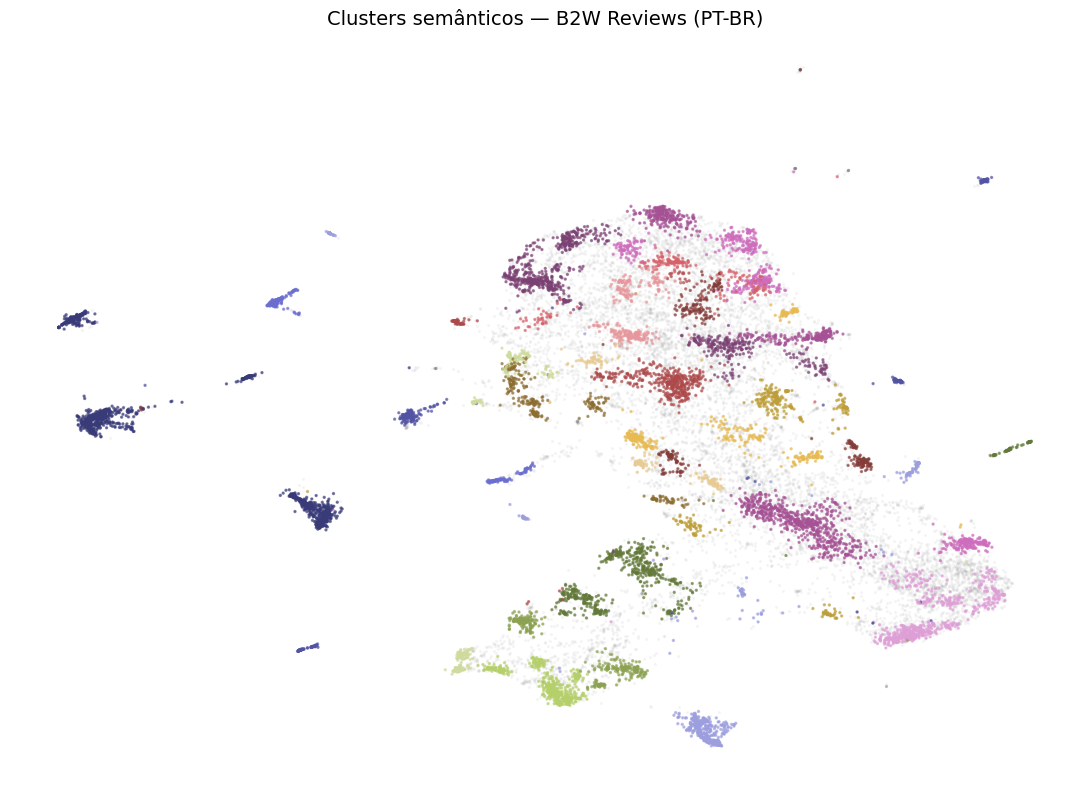

In [9]:
# =============================================================================
# Bloco 5 — Visualização 2D dos clusters
#           Slide 9
# =============================================================================
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(viz_embeddings, columns=["x", "y"])
df_plot["title"]   = titulos
df_plot["cluster"] = [str(c) for c in clusters]

to_plot  = df_plot.loc[df_plot.cluster != "-1", :]
outliers = df_plot.loc[df_plot.cluster == "-1", :]

plt.figure(figsize=(11, 8))
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    to_plot.x, to_plot.y,
    c=to_plot.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b",
)
plt.axis("off")
plt.title("Clusters semânticos — B2W Reviews (PT-BR)", fontsize=14)
plt.tight_layout()
plt.show()




In [14]:
# =============================================================================
# Bloco 6 — BERTopic com vetorizador em PORTUGUÊS
#           Slide 13
# -----------------------------------------------------------------------------
# IMPORTANTE: o CountVectorizer padrão do BERTopic usa stop words em inglês.
# Precisamos passar uma lista de stop words em português para que palavras
# como "que", "para", "uma", "muito" não dominem os tópicos.
#
# Usamos o pacote nltk para obter a lista. Se não tiver, baixe uma vez:
#   import nltk; nltk.download('stopwords')
# =============================================================================
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import nltk

# Baixa stop words se ainda não estiverem disponíveis
try:
    from nltk.corpus import stopwords
    stopwords_pt = stopwords.words("portuguese")
except LookupError:
    nltk.download("stopwords")
    from nltk.corpus import stopwords
    stopwords_pt = stopwords.words("portuguese")

# Stop words extras específicas de reviews (acrescente conforme observar)
stopwords_extras = [
    "produto", "comprei", "compra", "chegou", "veio", "loja",
    "americanas", "submarino", "shoptime", "site",
    "muito", "bem", "bom", "boa", "ótimo", "ótima", "excelente",
    "recomendo", "ainda", "agora", "hoje", "ontem",
    "pra", "pro", "tá", "tô",
]
stopwords_total = list(set(stopwords_pt + stopwords_extras))

vectorizer_model = CountVectorizer(
    stop_words=stopwords_total,
    min_df=5,        # ignora palavras que aparecem em menos de 5 reviews
    ngram_range=(1, 2),   # unigramas e bigramas (capta "boa qualidade", etc.)
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True,
    language="multilingual",
).fit(textos, embeddings)

# Visão geral
print(topic_model.get_topic_info().head(15))

# Palavras-chave de um tópico
print("\nTópico 0:")
for kw, score in topic_model.get_topic(0):
    print(f"  {kw:<25s} {score:.4f}")

# Busca semântica por tópico
ids, scores = topic_model.find_topics("entrega rápida")
print("\nTópicos similares a 'entrega rápida':", list(zip(ids, scores)))




2026-05-14 17:20:19,685 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-14 17:20:29,406 - BERTopic - Dimensionality - Completed ✓
2026-05-14 17:20:29,407 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-14 17:20:29,873 - BERTopic - Cluster - Completed ✓
2026-05-14 17:20:29,876 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-14 17:20:30,249 - BERTopic - Representation - Completed ✓


    Topic  Count                                               Name  \
0      -1   9897                  -1_entrega_prazo_recebi_qualidade   
1       0    643             0_peças_péssima_ruim_péssima qualidade   
2       1    532                    1_parabéns_lojas_sempre_entrega   
3       2    502                              2_nao_comprem_dia_ate   
4       3    420                              3_tv_imagem_smart_som   
5       4    378  4_expectativas_atendeu_atendeu expectativas_su...   
6       5    335                     5_lojas_recebi_nunca_parceiros   
7       6    309                6_celular_smartphone_telefone_todas   
8       7    288                  7_som_barulho_qualidade som_áudio   
9       8    268                         8_livro_leitura_ler_livros   
10      9    263  9_fácil_instalação_fácil instalação_fácil inst...   
11     10    239                      10_cabelo_cabelos_barba_deixa   
12     11    234                11_antes_antes prazo_previsto_prazo   
13    

In [17]:
# =============================================================================
# Bloco 7 — Visualizações nativas do BERTopic
#           Slide 14
# =============================================================================
fig_docs = topic_model.visualize_documents(
    titulos,
    reduced_embeddings=viz_embeddings,
    width=1200,
    hide_annotations=True,
)
fig_docs.show()





In [18]:
topic_model.visualize_barchart()


In [19]:
topic_model.visualize_heatmap(n_clusters=20)


In [20]:
topic_model.visualize_hierarchy()


In [21]:
# =============================================================================
# Bloco 8 — Refinamento com KeyBERTInspired
#           Slide 15
# =============================================================================
from copy import deepcopy
from bertopic.representation import KeyBERTInspired

original_topics = deepcopy(topic_model.topic_representations_)

representation_model = KeyBERTInspired()
topic_model.update_topics(
    textos,
    representation_model=representation_model,
    vectorizer_model=vectorizer_model,
)


def topic_differences(model, original_topics, nr_topics=5):
    """Compara representações antes e depois do representation model."""
    rows = []
    for topic_id in range(nr_topics):
        og = " | ".join([w for w, _ in original_topics[topic_id][:5]])
        new = " | ".join([w for w, _ in model.get_topic(topic_id)[:5]])
        rows.append({"Topic": topic_id, "Original": og, "Updated": new})
    return pd.DataFrame(rows)


# print(topic_differences(topic_model, original_topics))
topic_differences(topic_model, original_topics)




,Topic,Original,Updated
0,0,péssima qualidade | baixa qualidade | péssimo ...,péssima qualidade | baixa qualidade | péssimo ...
1,1,parabéns entrega | rápida parabéns | parabéns ...,parabéns entrega | rápida parabéns | parabéns ...
2,2,receber | entregue | porem | usar | vou,receber | entregue | porem | usar | vou
3,3,smart tv | tv | maravilhosa | super | cinema,smart tv | tv | maravilhosa | super | cinema
4,4,expectativas gostei | atendeu expectativas | s...,expectativas gostei | atendeu expectativas | s...


In [23]:
# =============================================================================
# Bloco 9 — Diversificando com MMR
#           Slide 16
# =============================================================================
from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.3)
topic_model.update_topics(
    textos,
    representation_model=representation_model,
    vectorizer_model=vectorizer_model,
)

# print(topic_differences(topic_model, original_topics))
topic_differences(topic_model, original_topics)



,Topic,Original,Updated
0,0,péssima qualidade | baixa qualidade | péssimo ...,peças | péssima qualidade | frágil | defeito |...
1,1,parabéns entrega | rápida parabéns | parabéns ...,parabéns | lojas | sempre | prazo | parabéns l...
2,2,receber | entregue | porem | usar | vou,comprem | recebi | 04 | entrega | prazo
3,3,smart tv | tv | maravilhosa | super | cinema,tv | smart | youtube | smart tv | aplicativos
4,4,expectativas gostei | atendeu expectativas | s...,atendeu expectativas | superou expectativas | ...


In [25]:
# =============================================================================
# Bloco 10 — Labels com DeepSeek (em português)
#            Slide 17
# -----------------------------------------------------------------------------
# Prompt traduzido para português para obter labels mais naturais em PT-BR.
# =============================================================================
from bertopic.representation import LiteLLM

if "DEEPSEEK_API_KEY" not in os.environ:
    raise RuntimeError(
        "Defina DEEPSEEK_API_KEY no .env. Obtenha em "
        "https://platform.deepseek.com/api_keys"
    )

prompt_deepseek_ptbr = """
Eu tenho um tópico que contém os seguintes documentos (avaliações de produtos):
[DOCUMENTS]

O tópico é descrito pelas seguintes palavras-chave: [KEYWORDS]

Com base nas informações acima, gere um rótulo curto e descritivo em português
brasileiro para este tópico, no formato:
tópico: <rótulo curto>
"""

representation_model = LiteLLM(
    model="deepseek/deepseek-chat",
    prompt=prompt_deepseek_ptbr,
    nr_docs=4,
    delay_in_seconds=1,
)

topic_model.update_topics(
    textos,
    representation_model=representation_model,
    vectorizer_model=vectorizer_model,
)

# Mostra os labels gerados para os 10 primeiros tópicos
print("\nLabels gerados pelo DeepSeek:")
for tid in range(10):
    label = topic_model.get_topic(tid)[0][0]
    count = (topic_model.topics_ == tid).sum()
    print(f"  Tópico {tid:>3d} ({count:>4d} docs): {label}")




100%|██████████| 75/75 [02:31<00:00,  2.02s/it]


Labels gerados pelo DeepSeek:


AttributeError: 'bool' object has no attribute 'sum'

In [24]:
# =============================================================================
# Bloco 10b — DeepSeek direto, com label + descrição estruturada
#             Slide 17
# -----------------------------------------------------------------------------
# Saída JSON para gerar tanto um label curto quanto uma descrição mais longa.
# Roda apenas nos top-20 tópicos (suficiente para apresentação).
# =============================================================================
import json
import time
from openai import OpenAI

deepseek_client = OpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com",
)

prompt_estruturado = """\
Você é um analista especializado em rotular agrupamentos de avaliações de produtos.

Tenho um tópico descrito pelas seguintes palavras-chave:
{keywords}

Algumas avaliações representativas deste tópico:
{documents}

Retorne um JSON com dois campos:
  - "rotulo":    rótulo conciso em português brasileiro (máximo 8 palavras)
  - "descricao": uma frase descrevendo o tópico em português brasileiro
"""

# Pega top-20 tópicos com mais documentos
top_topics = topic_model.get_topic_info().head(21).Topic.tolist()
top_topics = [t for t in top_topics if t != -1][:20]

deepseek_labels = {}
for tid in top_topics:
    info = topic_model.get_topic_info()
    row = info[info.Topic == tid].iloc[0]
    keywords = ", ".join(w for w, _ in topic_model.get_topic(tid))
    docs = "\n---\n".join(row.Representative_Docs[:3])

    resp = deepseek_client.chat.completions.create(
        model="deepseek-chat",
        messages=[{
            "role": "user",
            "content": prompt_estruturado.format(keywords=keywords, documents=docs),
        }],
        response_format={"type": "json_object"},
        temperature=0.0,
    )
    deepseek_labels[tid] = json.loads(resp.choices[0].message.content)
    print(f"\nTópico {tid}: {deepseek_labels[tid]['rotulo']}")
    print(f"  → {deepseek_labels[tid]['descricao']}")
    time.sleep(1)





Tópico 0: Péssima qualidade e defeitos
  → Os clientes reclamam da baixa qualidade do material, peças frágeis ou quebradas, e problemas na embalagem.

Tópico 1: Elogios à Americanas
  → Clientes parabenizam as Lojas Americanas pela entrega rápida e qualidade do serviço.

Tópico 2: Atraso na entrega
  → Clientes reclamam que não receberam o produto dentro do prazo, mesmo após pagamento.

Tópico 3: Smart TVs Samsung
  → Avaliações sobre smart TVs Samsung, destacando qualidade de imagem, aplicativos e conectividade.

Tópico 4: Atendeu expectativas
  → Avaliações que indicam que o produto atendeu ou superou as expectativas do cliente.

Tópico 5: Problemas com parceiros e cancelamentos
  → Clientes insatisfeitos com parceiros da Americanas, relatam não entrega, cancelamentos indevidos e dificuldade de reembolso.

Tópico 6: Celular rápido e bonito
  → Avaliações positivas sobre celulares rápidos, bonitos e que chegam antes do prazo.

Tópico 7: Qualidade de som e áudio
  → Avaliações sobre a

In [13]:
# =============================================================================
# Bloco 11 — Análise: tópicos vs nota das avaliações
#            (bônus didático: cruza com metadados estruturados)
# -----------------------------------------------------------------------------
# Como o B2W Reviews tem a nota de 1 a 5 estrelas, podemos cruzar para
# descobrir QUAIS tópicos estão associados a reviews negativos ou positivos.
# Insight valioso para análise de produto: identificar pontos de dor.
# =============================================================================
# Adiciona a coluna de tópico ao dataframe
df["topic"] = topic_model.topics_

# Nota média por tópico (descarta outliers)
ranking = (
    df.loc[df.topic != -1]
      .groupby("topic")
      .agg(media_nota=("overall_rating", "mean"),
           total=("overall_rating", "count"))
      .sort_values("media_nota")
      .head(10)
)

print("\n10 tópicos mais NEGATIVOS (menor nota média):")
for tid, row in ranking.iterrows():
    label = deepseek_labels.get(tid, {}).get("rotulo", "—")
    print(f"  Tópico {tid:>3d} | nota {row.media_nota:.2f} | "
          f"{int(row.total):>4d} reviews | {label}")


# =============================================================================
# FIM
# -----------------------------------------------------------------------------
# Próximos exercícios sugeridos para a aula:
#
#   1. Trocar o dataset por notícias da Folha (paulopirozelli/folha)
#      e ver como os tópicos descobertos diferem.
#
#   2. Comparar embeddings multilíngues vs. um modelo treinado em português
#      (ex: rufimelo/bert-large-portuguese-cased-sts).
#
#   3. Cruzar tópicos com a coluna 'product_category' para descobrir quais
#      tópicos transversais aparecem em várias categorias de produto.
#
#   4. Rodar BERTopic dinâmico (visualize_topics_over_time) usando a coluna
#      'submission_date' do dataset.
# =============================================================================


10 tópicos mais NEGATIVOS (menor nota média):


NameError: name 'deepseek_labels' is not defined